<font size=8> Chapter 6: Queue and Stack</font>

```python
def mono_stack(insert_entries):
    stack = []
    for entry in insert_entries:
        while(if) stack and stack[-1] <= entry:
            stack.pop()
            # Do something with the popped item here
        stack.append(entry)

from collections import deque
def queue_prob(): 
    queue = deque()
    result = []
    queue.append(root)
    while not all(item is None for item in queue):
        node = queue.popleft()

    return result

```

# Stack design

## Leetcode 1381. Design a Stack With Increment Operation (Medium)

Design a stack that supports increment operations on its elements.

Implement the CustomStack class:

- CustomStack(int maxSize) Initializes the object with maxSize which is the maximum number of elements in the stack.
- void push(int x) Adds x to the top of the stack if the stack has not reached the maxSize.
- int pop() Pops and returns the top of the stack or -1 if the stack is empty.
- void inc(int k, int val) Increments the bottom k elements of the stack by val. If there are less than k elements in the stack, increment all the elements in the stack.
 

Example 1:

- Input

["CustomStack","push","push","pop","push","push","push","increment","increment","pop","pop","pop","pop"]

[[3],[1],[2],[],[2],[3],[4],[5,100],[2,100],[],[],[],[]]

- Output

[null,null,null,2,null,null,null,null,null,103,202,201,-1]

Explanation
CustomStack stk = new CustomStack(3); // Stack is Empty []

stk.push(1);                          // stack becomes [1]

stk.push(2);                          // stack becomes [1, 2]

stk.pop();                            // return 2 --> Return top of the stack 2, stack becomes [1]

stk.push(2);                          // stack becomes [1, 2]

stk.push(3);                          // stack becomes [1, 2, 3]

stk.push(4);                          // stack still [1, 2, 3], Do not add another elements as size is 4

stk.increment(5, 100);                // stack becomes [101, 102, 103]

stk.increment(2, 100);                // stack becomes [201, 202, 103]

stk.pop();                            // return 103 --> Return top of the stack 103, stack becomes [201, 202]

stk.pop();                            // return 202 --> Return top of the stack 202, stack becomes [201]

stk.pop();                            // return 201 --> Return top of the stack 201, stack becomes []

stk.pop();                            // return -1 --> Stack is empty return -1.
 

ideas :

The straightforward approach would be to use a simple array to simulate the stack and directly modify elements during the increment operation. However, this would make the increment operation O(k) in time complexity, as we'd need to iterate through and update k elements.

The key insight is that we can defer the actual increments until we need to access the elements.

Instead of immediately applying the increment to all k elements, we can just "mark" that an increment needs to be applied. We use a separate array add where add[i] stores the cumulative increment that should be applied to the element at position i when it's accessed.

The clever part comes with how we handle these increments during the pop operation. When we pop an element at position i, we:

- Apply the increment stored at add[i] to get the actual value
- Pass this increment down to the element below it (add[i-1] += add[i])
- Clear the increment at position i since we've already used it

In [ ]:
# lazy popu
class CustomStack():
    def __init__(self, maxSize):
        self.stack = [0] * maxSize
        self.add = [0] * maxSize
        self.maxSize = maxSize
        self.length = 0

    def push(self, n):
        if self.length < self.maxSize:
            self.stack[self.length] = n
            self.length += 1

    def pop(self):
        if self.length > 0:
            sol = self.stack[self.length-1] + self.add[self.length-1]
            self.length -= 1
            if self.length > 0:
                self.add[self.length-1] += self.add[self.length]
            return sol
        else:
            return -1 

    def increment(self,k, val):
        index = min(k-1, self.length-1)
        if index >= 0:
            self.add[index] += val

In [ ]:
customStack = CustomStack(3);
customStack.push(1)
customStack.push(2)
customStack.pop()

In [ ]:
customStack.push(2)  
customStack.push(3)    
customStack.push(4)      
customStack.increment(5, 100)
customStack.increment(2, 100) 
customStack.pop()
customStack.pop()
customStack.pop()
customStack.pop()

## Leetcode 155. Min Stack (Medium)

Description:
Design a stack that supports push, pop, top, and retrieving the minimum element in constant time.

push(x) -- Push element x onto stack.
pop( ) -- Removes the element on top of the stack.
top( ) -- Get the top element.
getMin( ) -- Retrieve the minimum element in the stack.

- Example:
Input:

["MinStack","push","push","push","getMin","pop","top","getMin"]

[ [ ],[-2],[0],[-3],[ ],[ ],[ ],[ ] ]

Output:

[null,null,null,null,-3,null,0,-2]

In [ ]:
import math
class MinStack():
    def __init__(self):
        self.stack = []
        self.stack_min = [math.inf]
    def push(self, num):
        self.stack.append(num)
        self.stack_min.append(min(num, self.stack_min[-1]))
    def pop(self):
        if len(self.stack)>0:
            self.stack.pop()
            self.stack_min.pop()
    def getMin(self):
        return self.stack_min[-1]
    def top(self):
        return self.stack[-1]       

In [ ]:
minstack = MinStack()
minstack = MinStack()
minstack.push(-2)
minstack.push(0)
minstack.push(-3)
minstack.getMin()

In [ ]:
minstack.pop()
minstack.top()

In [ ]:
minstack.getMin()

## Leetcode 716. Max Stack
Design a max stack that supports push, pop, top, peekMax and popMax.

push(x) -- Push element x onto stack.
pop() -- Remove the element on top of the stack and return it.
top() -- Get the element on the top.
peekMax() -- Retrieve the maximum element in the stack.
popMax() -- Retrieve the maximum element in the stack, and remove it. If you find more than one maximum elements, only remove the top-most one.
- Example 1:
```
MaxStack stack = new MaxStack();
stack.push(5);
stack.push(1);
stack.push(5);
stack.top(); -> 5
stack.popMax(); -> 5
stack.top(); -> 1
stack.peekMax(); -> 5
stack.pop(); -> 1
stack.top(); -> 5
```

## Leetcode 232. Implement Queue using Stacks

Description:
Implement the following operations of a queue using stacks.

push(x) -- Push element x to the back of queue.

pop() -- Removes the element from in front of queue.

peek() -- Get the front element.

empty() -- Return whether the queue is empty.

Note:
You must use only standard operations of a stack -- which means only push to top, peek/pop from top, size, and is empty operations are valid.
Depending on your language, stack may not be supported natively. You may simulate a stack by using a list or deque (double-ended queue), as long as you use only standard operations of a stack.
You may assume that all operations are valid (for example, no pop or peek operations will be called on an empty queue).

Example 1:

Input
["MyQueue", "push", "push", "peek", "pop", "empty"]

[[], [1], [2], [], [], []]

Output
[null, null, null, 1, 1, false]

Explanation

MyQueue myQueue = new MyQueue();

myQueue.push(1); // queue is: [1]

myQueue.push(2); // queue is: [1, 2] (leftmost is front of the queue)

myQueue.peek(); // return 1

myQueue.pop(); // return 1, queue is [2]

myQueue.empty(); // return false

In [64]:
class MyQueue():
    def __init__(self):
        self.stack1 = []
        self.stack2 = []
    def push(self, num):
        self.stack1.append(num)
    def move(self):
        if not self.stack2:
            while self.stack1:
                self.stack2.append(self.stack1.pop())
    def pop(self):
        self.move()
        return self.stack2.pop()
    def top(self):
        self.move()
        return self.stack2.top()
    def peek(self):
        self.move()
        return self.stack2[-1]
    def empty(self):
        return (not self.stack1) and (not self.stack2)

In [65]:
myQueue = MyQueue()
myQueue.push(1)
myQueue.push(2)
myQueue.peek()

1

In [66]:
myQueue.pop()

1

In [67]:
myQueue.empty()

False

In [96]:
class MyQueue():
    def __init__(self):
        self.stack1 = []
        self.stack2 = []
    def push(self, num):
        self.stack1.append(num)
    def pop(self):
        self.move()
        return self.stack2.pop()
    def peek(self):
        self.move()
        return self.stack2[-1]
    def empty(self):
        return not self.stack1 and not self.stack2
    def move(self):
        if not self.stack2:
            while self.stack1:
                self.stack2.append(self.stack1.pop())

In [97]:
myQueue = MyQueue()
myQueue.push(1)
myQueue.push(2)
myQueue.peek()

1

In [98]:
myQueue.pop()

1

In [99]:
myQueue.empty()

False

# monotonic stack

## Leetcode 496. Next Greater Element I

Description:
You are given two arrays (without duplicates) nums1 and nums2 where nums1’s elements are subset of nums2. Find all the next greater numbers for nums1’s elements in the corresponding places of nums2.

The Next Greater Number of a number x in nums1 is the first greater number to its right in nums2. If it does not exist, output -1 for this number.

Note:
All elements in nums1 and nums2 are unique.
The length of both nums1 and nums2 would not exceed 1000.

- Example1:
Input: nums1 = [4,1,2], nums2 = [1,3,4,2].

Output: [-1,3,-1]

Explanation:

For number 4 in the first array, you cannot find the next greater number for it in the second array, so output -1.
For number 1 in the first array, the next greater number for it in the second array is 3.
For number 2 in the first array, there is no next greater number for it in the second array, so output -1.

- Example2:
Input: nums1 = [2,4], nums2 = [1,2,3,4].

Output: [3,-1]

Explanation:

For number 2 in the first array, the next greater number for it in the second array is 3.
For number 4 in the first array, there is no next greater number for it in the second array, so output -1.

In [25]:
def nextGreaterElement(nums1, nums2):
    stack = []
    myDict = {}
    for num in nums2[::-1]:
        while stack and stack[-1] < num:
            stack.pop()
        if stack:
            myDict[num] = stack[-1]
        stack.append(num)
    return [myDict.get(num, -1) for num in nums1]

In [26]:
nextGreaterElement([4,1,2],[1,3,4,2])

[-1, 3, -1]

In [27]:
nextGreaterElement([2,4],[1,2,3,4])

[3, -1]

In [84]:
def nextGreaterElement(nums1, nums2):
    stack = []
    myDict = {}
    for num in nums2[::-1]:
        while stack and stack[-1] < num:
            stack.pop()
        if stack:
            myDict[num] = stack[-1]
        stack.append(num)
    print(myDict)
    return [myDict.get(i, -1) for i in nums1]

In [85]:
nextGreaterElement([4,1,2],[1,3,4,2])

{3: 4, 1: 3}


[-1, 3, -1]

In [86]:
nextGreaterElement([2,4],[1,2,3,4])

{3: 4, 2: 3, 1: 2}


[3, -1]

In [112]:
def nextGreaterElement(num1, num2):
    stack = []
    myDict = {}
    result = []
    for num in num2[::-1]:
        while stack and stack[-1] < num:
            stack.pop()
        if stack:
            myDict[num] = stack[-1]
        stack.append(num)
    for num in num1:
        result.append(myDict.get(num, -1))
    return result

In [113]:
nextGreaterElement([4,1,2],[1,3,4,2])

[-1, 3, -1]

In [114]:
nextGreaterElement([2,4],[1,2,3,4])

[3, -1]

## Leetcode 503. Next Greater Element II (Medium)

Given a circular integer array nums (i.e., the next element of nums[nums.length - 1] is nums[0]), return the next greater number for every element in nums.

The next greater number of a number x is the first greater number to its traversing-order next in the array, which means you could search circularly to find its next greater number. If it doesn't exist, return -1 for this number.

- Example 1:

Input: nums = [1,2,1]
Output: [2,-1,2]

Explanation: The first 1's next greater number is 2; 
The number 2 can't find next greater number. 
The second 1's next greater number needs to search circularly, which is also 2.

- Example 2:

Input: nums = [1,2,3,4,3]
Output: [2,3,4,-1,4]

## Leetcode 1019. Next Greater Node In Linked List (Medium)

You are given the head of a linked list with n nodes.

For each node in the list, find the value of the next greater node. That is, for each node, find the value of the first node that is next to it and has a strictly larger value than it.

Return an integer array answer where answer[i] is the value of the next greater node of the ith node (1-indexed). If the ith node does not have a next greater node, set answer[i] = 0.

- Example 1:


Input: head = [2,1,5]
Output: [5,5,0]
- Example 2:


Input: head = [2,7,4,3,5]
Output: [7,0,5,5,0]

## Leetcode 739. Daily Temperatures (Medium)

Given an array of integers temperatures represents the daily temperatures, return an array answer such that answer[i] is the number of days you have to wait after the ith day to get a warmer temperature. If there is no future day for which this is possible, keep answer[i] == 0 instead.

- Example 1:

Input: temperatures = [73,74,75,71,69,72,76,73]
Output: [1,1,4,2,1,1,0,0]
- Example 2:

Input: temperatures = [30,40,50,60]
Output: [1,1,1,0]
- Example 3:

Input: temperatures = [30,60,90]
Output: [1,1,0]

## Leetcode 316. Remove Duplicate Letters (Medium)

Given a string s, remove duplicate letters so that every letter appears once and only once. You must make sure your result is the smallest in lexicographical order among all possible results.

- Example 1:

Input: s = "bcabc"
Output: "abc"
- Example 2:

Input: s = "cbacdcbc"
Output: "acdb"

## Leetcode 42. Trapping Rain Water (Hard)

Given n non-negative integers representing an elevation map where the width of each bar is 1, compute how much water it can trap after raining.
- Example 1:

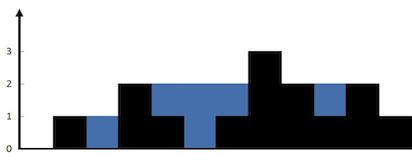

Input: height = [0,1,0,2,1,0,1,3,2,1,2,1]
Output: 6
Explanation: The above elevation map (black section) is represented by array [0,1,0,2,1,0,1,3,2,1,2,1]. In this case, 6 units of rain water (blue section) are being trapped.

## Leetcode 84. Largest Rectangle in Histogram (Hard)

Given an array of integers heights representing the histogram's bar height where the width of each bar is 1, return the area of the largest rectangle in the histogram.

- Example 1:

Input: heights = [2,1,5,6,2,3]
Output: 10
Explanation: The above is a histogram where width of each bar is 1.
The largest rectangle is shown in the red area, which has an area = 10 units.

- Example 2:

Input: heights = [2,4]
Output: 4

# Stack Application

- 栈的模拟
- 括号的匹配

## Leetcode 1544. Make The String Great
Given a string s of lower and upper case English letters.

A good string is a string which doesn't have two adjacent characters s[i] and s[i + 1] where:

0 <= i <= s.length - 2
s[i] is a lower-case letter and s[i + 1] is the same letter but in upper-case or vice-versa.
To make the string good, you can choose two adjacent characters that make the string bad and remove them. You can keep doing this until the string becomes good.

Return the string after making it good. The answer is guaranteed to be unique under the given constraints.

Notice that an empty string is also good.

- Example 1:

Input: s = "leEeetcode"
Output: "leetcode"
Explanation: In the first step, either you choose i = 1 or i = 2, both will result "leEeetcode" to be reduced to "leetcode".
- Example 2:

Input: s = "abBAcC"
Output: ""
Explanation: We have many possible scenarios, and all lead to the same answer. For example:
"abBAcC" --> "aAcC" --> "cC" --> ""
"abBAcC" --> "abBA" --> "aA" --> ""
- Example 3:

Input: s = "s"
Output: "s"

## Leetcode 1598. Crawler Log Folder

The Leetcode file system keeps a log each time some user performs a change folder operation.

The operations are described below:

"../" : Move to the parent folder of the current folder. (If you are already in the main folder, remain in the same folder).
"./" : Remain in the same folder.
"x/" : Move to the child folder named x (This folder is guaranteed to always exist).
You are given a list of strings logs where logs[i] is the operation performed by the user at the ith step.

The file system starts in the main folder, then the operations in logs are performed.

Return the minimum number of operations needed to go back to the main folder after the change folder operations.

Example 1:

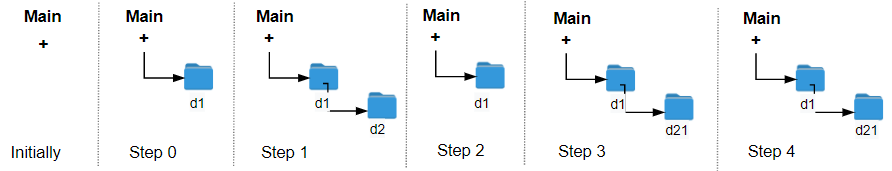

Input: logs = ["d1/","d2/","../","d21/","./"]
Output: 2
Explanation: Use this change folder operation "../" 2 times and go back to the main folder.
- Example 2:

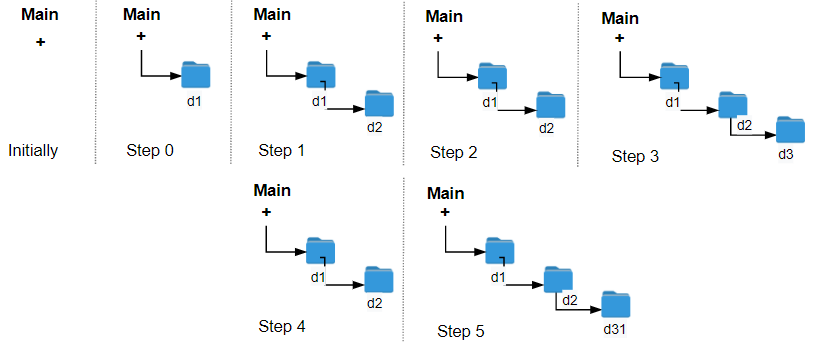

Input: logs = ["d1/","d2/","./","d3/","../","d31/"]
Output: 3
- Example 3:

Input: logs = ["d1/","../","../","../"]
Output: 0

## Leetcode 1472. Design Browser History (Medium)

You have a browser of one tab where you start on the homepage and you can visit another url, get back in the history number of steps or move forward in the history number of steps.

Implement the BrowserHistory class:

BrowserHistory(string homepage) Initializes the object with the homepage of the browser.
void visit(string url) Visits url from the current page. It clears up all the forward history.
string back(int steps) Move steps back in history. If you can only return x steps in the history and steps > x, you will return only x steps. Return the current url after moving back in history at most steps.
string forward(int steps) Move steps forward in history. If you can only forward x steps in the history and steps > x, you will forward only x steps. Return the current url after forwarding in history at most steps.
 

Example:

Input:
```
["BrowserHistory","visit","visit","visit","back","back","forward","visit","forward","back","back"]
[["leetcode.com"],["google.com"],["facebook.com"],["youtube.com"],[1],[1],[1],["linkedin.com"],[2],[2],[7]]
Output:
[null,null,null,null,"facebook.com","google.com","facebook.com",null,"linkedin.com","google.com","leetcode.com"]
```

Explanation:
```
BrowserHistory browserHistory = new BrowserHistory("leetcode.com");
browserHistory.visit("google.com");       // You are in "leetcode.com". Visit "google.com"
browserHistory.visit("facebook.com");     // You are in "google.com". Visit "facebook.com"
browserHistory.visit("youtube.com");      // You are in "facebook.com". Visit "youtube.com"
browserHistory.back(1);                   // You are in "youtube.com", move back to "facebook.com" return "facebook.com"
browserHistory.back(1);                   // You are in "facebook.com", move back to "google.com" return "google.com"
browserHistory.forward(1);                // You are in "google.com", move forward to "facebook.com" return "facebook.com"
browserHistory.visit("linkedin.com");     // You are in "facebook.com". Visit "linkedin.com"
browserHistory.forward(2);                // You are in "linkedin.com", you cannot move forward any steps.
browserHistory.back(2);                   // You are in "linkedin.com", move back two steps to "facebook.com" then to "google.com". return "google.com"
browserHistory.back(7);                   // You are in "google.com", you can move back only one step to "leetcode.com". return "leetcode.com"
```

## Leetcode 71. Simplify Path (Medium)

You are given an absolute path for a Unix-style file system, which always begins with a slash '/'. Your task is to transform this absolute path into its simplified canonical path.

The rules of a Unix-style file system are as follows:

A single period '.' represents the current directory.
A double period '..' represents the previous/parent directory.
Multiple consecutive slashes such as '//' and '///' are treated as a single slash '/'.
Any sequence of periods that does not match the rules above should be treated as a valid directory or file name. For example, '...' and '....' are valid directory or file names.
The simplified canonical path should follow these rules:

The path must start with a single slash '/'.
Directories within the path must be separated by exactly one slash '/'.
The path must not end with a slash '/', unless it is the root directory.
The path must not have any single or double periods ('.' and '..') used to denote current or parent directories.
Return the simplified canonical path.

- Example 1:

Input: path = "/home/"

Output: "/home"

Explanation: The trailing slash should be removed.

- Example 2:

Input: path = "/home//foo/"

Output: "/home/foo"

Explanation:Multiple consecutive slashes are replaced by a single one.

- Example 3:

Input: path = "/home/user/Documents/../Pictures"

Output: "/home/user/Pictures"

Explanation: A double period ".." refers to the directory up a level (the parent directory).

- Example 4:

Input: path = "/../"

Output: "/"

Explanation:Going one level up from the root directory is not possible.

- Example 5:

Input: path = "/.../a/../b/c/../d/./"

Output: "/.../b/d"

Explanation: "..." is a valid name for a directory in this problem.

## Leetcode 1047. Remove All Adjacent Duplicates In String

Description:
Given a string S of lowercase letters, a duplicate removal consists of choosing two adjacent and equal letters, and removing them.
We repeatedly make duplicate removals on S until we no longer can.

Return the final string after all such duplicate removals have been made. It is guaranteed the answer is unique.

Note:
<= S.length <= 20000.
consists only of English lowercase letters.

- Example 1:

Input: s = "abbaca"
Output: "ca"
Explanation: 
For example, in "abbaca" we could remove "bb" since the letters are adjacent and equal, and this is the only possible move.  The result of this move is that the string is "aaca", of which only "aa" is possible, so the final string is "ca".
- Example 2:

Input: s = "azxxzy"
Output: "ay"

In [32]:
def removeAllAdj(string):
    stack = []
    for s in string:
        if stack and stack[-1] == s:
            stack.pop()
        else:
            stack.append(s)
    return ''.join(stack)

In [33]:
removeAllAdj("abbaca")

'ca'

In [34]:
removeAllAdj("azxxzy")

'ay'

In [16]:
def removeAllAdj(s):
    stack = []
    for a in s:
        if stack and stack[-1] == a:
            stack.pop()
        else:
            stack.append(a)
    return ''.join(stack)

In [17]:
removeAllAdj("abbaca")

'ca'

In [18]:
removeAllAdj("azxxzy")

'ay'

In [7]:
def removeAllAdj(string):
    stack = []
    for c in string:
        if len(stack) > 0 and stack[-1] == c:
            stack.pop()
        else:
            stack.append(c)
            
    return ''.join(stack)

In [8]:
removeAllAdj("abbaca")

'ca'

## Leetcode 1021. Remove Outermost Parentheses

A valid parentheses string is either empty "", "(" + A + ")", or A + B, where A and B are valid parentheses strings, and + represents string concatenation.

For example, "", "()", "(())()", and "(()(()))" are all valid parentheses strings.
A valid parentheses string s is primitive if it is nonempty, and there does not exist a way to split it into s = A + B, with A and B nonempty valid parentheses strings.

Given a valid parentheses string s, consider its primitive decomposition: s = P1 + P2 + ... + Pk, where Pi are primitive valid parentheses strings.

Return s after removing the outermost parentheses of every primitive string in the primitive decomposition of s.

- Example 1:

Input: s = "(()())(())", Output: "()()()"

Explanation: 
The input string is "(()())(())", with primitive decomposition "(()())" + "(())".
After removing outer parentheses of each part, this is "()()" + "()" = "()()()".

- Example 2:

Input: s = "(()())(())(()(()))", Output: "()()()()(())"

Explanation: 
The input string is "(()())(())(()(()))", with primitive decomposition "(()())" + "(())" + "(()(()))".
After removing outer parentheses of each part, this is "()()" + "()" + "()(())" = "()()()()(())".

- Example 3:

Input: s = "()()", Output: ""

Explanation: 
The input string is "()()", with primitive decomposition "()" + "()".
After removing outer parentheses of each part, this is "" + "" = "".

In [40]:
def removeOutermostParentheses(string):
    stack = []
    result = []
    for s in string:
        if s == '(':
            if stack:
                result.append(s)
            stack.append(s)
        elif s == ')':
            stack.pop()
            if stack:
                result.append(s)
    return ''.join(result)

In [41]:
removeOutermostParentheses("(()())(())")

'()()()'

In [42]:
removeOutermostParentheses("(()())(())(()(()))")

'()()()()(())'

In [39]:
removeOutermostParentheses("()()")

''

In [19]:
def removeOutermostParentheses(string):
    stack =[]
    cnt = 0
    for s in string:
        if s == '(':
            cnt += 1
            if cnt > 1:
                stack.append(s)
        else:
            cnt -= 1
            if cnt > 0:
                stack.append(s)
    return ''.join(stack)
        

In [20]:
removeOutermostParentheses("(()())(())")

'()()()'

In [21]:
removeOutermostParentheses("(()())(())(()(()))")

'()()()()(())'

In [22]:
removeOutermostParentheses("()()")

''

In [27]:
removeOutermostParentheses("(()())(())")

'()()()'

In [28]:
removeOutermostParentheses("(()())(())(()(()))")

'()()()()(())'

In [29]:
removeOutermostParentheses("()()")

''

## Leetcode 20. Valid Parentheses

Description:
Given a string containing just the characters "(", ")", "{", "}", "[" and "]", determine if the input string is valid.

An input string is valid if:

Open brackets must be closed by the same type of brackets.
Open brackets must be closed in the correct order.
Note:
That an empty string is also considered valid.

- Example1:
Input: "( )" Output: true

- Example2:
Input: "( ) [ ] { }" Output: true

- Example3:
Input: "( ]" Output: false

- Example4:
Input: "( [ ) ]" Output: false

- Example5:
Input: "{ [ ] }" Output: true

In [43]:
def validParentheses(string):
    myDict = {')':'(',']':'[','}':'{'}
    stack = []
    for s in string:
        if s in myDict:
            if stack and stack[-1] == myDict[s]:
                stack.pop()
        elif s in myDict.values():
            stack.append(s)
    if stack:
        return False
    else:
        return True

In [44]:
validParentheses("()")

True

In [45]:
validParentheses("()[]{}")

True

In [46]:
validParentheses("([)]")

False

In [47]:
validParentheses("{[]}")

True

In [23]:
def validParentheses(string):
    stack=[]
    myDict = {')':'(', ']':'[', '}':'{'}
    for s in string:
        if s in myDict:
            if stack and stack[-1] == myDict[s]:
                stack.pop()
        else:
            stack.append(s)
    if stack:
        return False
    else:
        return True

In [26]:
validParentheses("()")

True

In [28]:
validParentheses("()[]{}")

True

In [29]:
validParentheses("([)]")

False

In [30]:
validParentheses("{[]}")

True

In [37]:
def validParentheses(string):
    myDict = {')':'(', ']':'[', '}':'{'}
    stack = []
    for c in string:
        if c in myDict.values():
            stack.append(c)
        elif c in myDict:
            if len(stack) > 0 and stack[-1] == myDict[c]:
                stack.pop()
            elif len(stack) > 0 and stack[-1] != myDict[c]:
                return False
        elif c in [' ']:
            continue
    return len(stack) == 0
            

In [38]:
validParentheses("()")

True

In [39]:
validParentheses("( ) [ ] { }")

True

In [40]:
validParentheses("([)]")

False

In [41]:
validParentheses("{ [ ] }")

True

## Leetcode 636. Exclusive Time of Functions(Medium)

On a single-threaded CPU, we execute a program containing n functions. Each function has a unique ID between 0 and n - 1.

Function calls are stored in a call stack: when a function call starts, its ID is pushed onto the stack, and when a function call ends, its ID is popped off the stack. The function whose ID is at the top of the stack is the current function being executed. Each time a function starts or ends, we write a log with the ID, whether it started or ended, and the timestamp.

You are given a list logs, where logs[i] represents the ith log message formatted as a string "{function_id}:{"start" | "end"}:{timestamp}". For example, "0:start:3" means a function call with function ID 0 started at the beginning of timestamp 3, and "1:end:2" means a function call with function ID 1 ended at the end of timestamp 2. Note that a function can be called multiple times, possibly recursively.

A function's exclusive time is the sum of execution times for all function calls in the program. For example, if a function is called twice, one call executing for 2 time units and another call executing for 1 time unit, the exclusive time is 2 + 1 = 3.

Return the exclusive time of each function in an array, where the value at the ith index represents the exclusive time for the function with ID i.

Example 1:

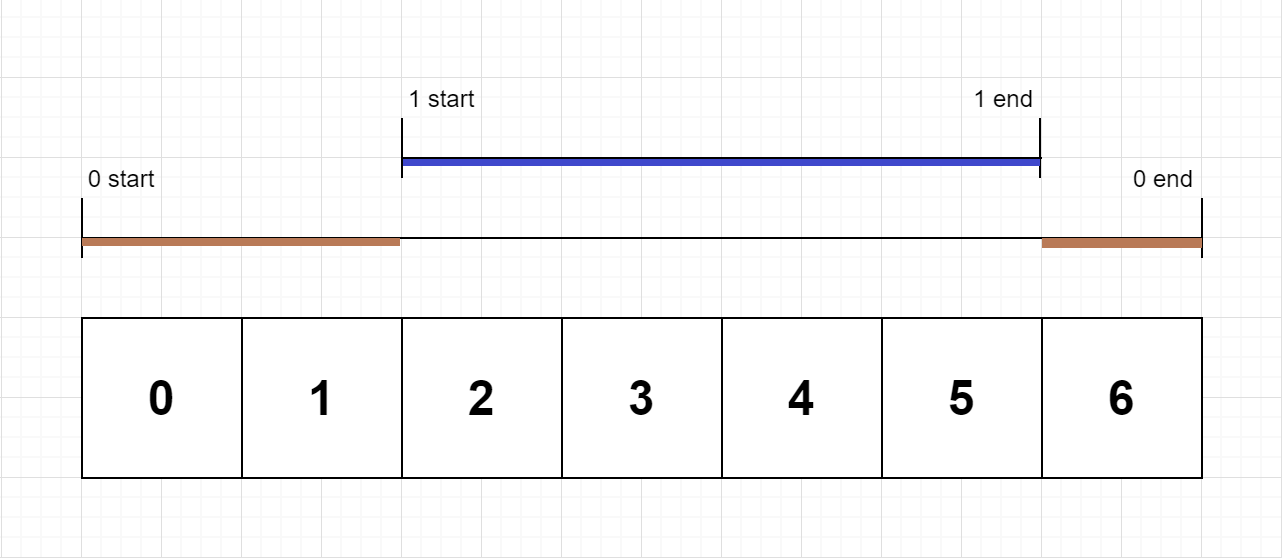

Input: n = 2, logs = ["0:start:0","1:start:2","1:end:5","0:end:6"]
Output: [3,4]
Explanation:
Function 0 starts at the beginning of time 0, then it executes 2 for units of time and reaches the end of time 1.
Function 1 starts at the beginning of time 2, executes for 4 units of time, and ends at the end of time 5.
Function 0 resumes execution at the beginning of time 6 and executes for 1 unit of time.
So function 0 spends 2 + 1 = 3 units of total time executing, and function 1 spends 4 units of total time executing.
Example 2:

Input: n = 1, logs = ["0:start:0","0:start:2","0:end:5","0:start:6","0:end:6","0:end:7"]
Output: [8]
Explanation:
Function 0 starts at the beginning of time 0, executes for 2 units of time, and recursively calls itself.
Function 0 (recursive call) starts at the beginning of time 2 and executes for 4 units of time.
Function 0 (initial call) resumes execution then immediately calls itself again.
Function 0 (2nd recursive call) starts at the beginning of time 6 and executes for 1 unit of time.
Function 0 (initial call) resumes execution at the beginning of time 7 and executes for 1 unit of time.
So function 0 spends 2 + 4 + 1 + 1 = 8 units of total time executing.
Example 3:

Input: n = 2, logs = ["0:start:0","0:start:2","0:end:5","1:start:6","1:end:6","0:end:7"]
Output: [7,1]
Explanation:
Function 0 starts at the beginning of time 0, executes for 2 units of time, and recursively calls itself.
Function 0 (recursive call) starts at the beginning of time 2 and executes for 4 units of time.
Function 0 (initial call) resumes execution then immediately calls function 1.
Function 1 starts at the beginning of time 6, executes 1 unit of time, and ends at the end of time 6.
Function 0 resumes execution at the beginning of time 7 and executes for 1 unit of time.
So function 0 spends 2 + 4 + 1 = 7 units of total time executing, and function 1 spends 1 unit of total time executing.

## Leetcode 1249. Minimum Remove to Make Valid Parentheses(Medium)

Given a string s of '(' , ')' and lowercase English characters.

Your task is to remove the minimum number of parentheses ( '(' or ')', in any positions ) so that the resulting parentheses string is valid and return any valid string.

Formally, a parentheses string is valid if and only if:

It is the empty string, contains only lowercase characters, or
It can be written as AB (A concatenated with B), where A and B are valid strings, or
It can be written as (A), where A is a valid string.
 
- Example 1:

Input: s = "lee(t(c)o)de)"
Output: "lee(t(c)o)de"
Explanation: "lee(t(co)de)" , "lee(t(c)ode)" would also be accepted.
- Example 2:

Input: s = "a)b(c)d"
Output: "ab(c)d"
- Example 3:

Input: s = "))(("
Output: ""
Explanation: An empty string is also valid.

## Leetcode 32. Longest Valid Parentheses (Hard)

Given a string containing just the characters '(' and ')', return the length of the longest valid (well-formed) parentheses substring.

- Example 1:

Input: s = "(()"
Output: 2
Explanation: The longest valid parentheses substring is "()".

- Example 2:

Input: s = ")()())"
Output: 4
Explanation: The longest valid parentheses substring is "()()".

- Example 3:

Input: s = ""
Output: 0

In [ ]:
myStack = MyStack()
myStack.push(1)
myStack.push(2)
myStack.top()

In [ ]:
myStack.pop()

In [ ]:
myStack.empty()

In [102]:
from collections import deque
class MyStack:
    def __init__(self):
        self.queue1 = deque()
        self.queue2 = deque()
    def push(self, num):
        self.queue2.append(num)
        while self.queue1:
            self.queue2.append(self.queue1.popleft())
        self.queue1, self.queue2 = self.queue2, self.queue1
    def top(self):
        return self.queue1[0]
    def pop(self):
        return self.queue1.popleft()        
    def empty(self):
        return len(self.queue1) == 0

In [103]:
myStack = MyStack()
myStack.push(1)
myStack.push(2)
myStack.top()

In [105]:
myStack.pop()

2

In [106]:
myStack.empty()

False

## Leetcode 682. Baseball Game

Description:
You’re now a baseball game point recorder.
Given a list of strings, each string can be one of the 4 following types:

Integer (one round’s score): Directly represents the number of points you get in this round.
"+" (one round’s score): Represents that the points you get in this round are the sum of the last two valid round’s points.
"D" (one round’s score): Represents that the points you get in this round are the doubled data of the last valid round’s points.
"C" (an operation, which isn’t a round’s score): Represents the last valid round’s points you get were invalid and should be removed.
Each round’s operation is permanent and could have an impact on the round before and the round after.

You need to return the sum of the points you could get in all the rounds.

Note:
The size of the input list will be between 1 and 1000.
Every integer represented in the list will be between -30000 and 30000.
Example1:
Input: ["5","2","C","D","+"]
Output: 30

Explanation:

Round 1: You could get 5 points. The sum is: 5.
Round 2: You could get 2 points. The sum is: 7.
Operation 1: The round 2’s data was invalid. The sum is: 5.
Round 3: You could get 10 points (the round 2’s data has been removed). The sum is: 15.
Round 4: You could get 5 + 10 = 15 points. The sum is: 30.

- Example2:
Input: ["5","-2","4","C","D","9","+","+"]
Output: 27

Explanation:

- Round 1: You could get 5 points. The sum is: 5.
- Round 2: You could get -2 points. The sum is: 3.
- Round 3: You could get 4 points. The sum is: 7.
    Operation 1: The round 3’s data is invalid. The sum is: 3.
- Round 4: You could get -4 points (the round 3’s data has been removed). The sum is: -1.
- Round 5: You could get 9 points. The sum is: 8.
- Round 6: You could get -4 + 9 = 5 points. The sum is 13.
- Round 7: You could get 9 + 5 = 14 points. The sum is 27.


In [9]:
def baseballGame(nums):
    stack = []
    result = 0
    for num in nums:
        if num[0] == '-':
            result += int(num)
            stack.append(int(num))
        elif num.isdigit():
            result += int(num)
            stack.append(int(num))
        elif num =='C':            
            result -= stack.pop()
        elif num == 'D':
            n = stack[-1]
            stack.append(2*n)
            result += 2*n
        elif num == '+':
            n = stack[-1] + stack[-2]
            stack.append(n)
            result += n
    return result 

In [10]:
baseballGame(["5","2","C","D","+"])

5
7
5
15
30


30

In [11]:
baseballGame(["5","-2","4","C","D","9","+","+"])

5
3
7
3
-1
8
13
27


27

In [75]:
def baseballGame(strList):
    result = 0
    stack = []
    for s in strList:
        if s[0]=='-':
            num = int(s)
            stack.append(num)
            result += num
        elif s.isdigit():
            num = int(s)
            stack.append(num)
            result += num
        elif s == 'D':
            num = stack[-1]*2
            stack.append(num)
            result += num
        elif s == 'C':
            num = stack.pop()
            result -= num
        elif s == '+':
            num1 = stack[-1]
            num2 = stack[-2]
            total = num1+num2
            result += total
            stack.append(total)
    return result

In [76]:
baseballGame(["5","2","C","D","+"])

30

In [77]:
baseballGame(["5","-2","4","C","D","9","+","+"])

27

In [67]:
def baseballGame(slist):
    stack = []
    result = 0
    for s in slist:
        
        if s.isnumeric():
            result += int(s)
            stack.append(int(s))
        elif s[0]=='-':
            result += int(s)
            stack.append(int(s))
        elif s == 'C' and len(stack) > 0:
            num = stack.pop()
            result -= num
        elif s == 'D' and len(stack) > 0:
            num = stack[-1] * 2
            stack.append(num)
            result += num
        elif s == '+' and len(stack) > 1:
            num1 = stack[-1]
            num2 = stack[-2]
            result += (num1+num2)
            stack.append(num1+num2)

    return result

In [68]:
baseballGame(["5","2","C","D","+"])

30

In [69]:
baseballGame(["5","-2","4","C","D","9","+","+"])

27

## Leetcode 844. Backspace String Compare

Description:
Given two strings S and T, return if they are equal when both are typed into empty text editors. # means a backspace character.

Note that after backspacing an empty text, the text will continue empty.

Note:
1 <= S.length <= 200
1 <= T.length <= 200
S and T only contain lowercase letters and "#" characters.

- Example1:
Input: S = "ab#c", T = "ad#c"
Output: true

Explanation: Both S and T become "ac".

- Example2:
Input: S = "ab##", T = "c#d#"
Output: true

Explanation: Both S and T become "".

- Example3:
Input: S = "a##c", T = "#a#c"
Output: true

Explanation: Both S and T become "c".

- Example4:
Input: S = "a#c", T = "b"
Output: false

Explanation: S becomes "c" while T becomes "b".

Follow up:
Can you solve it in O(N) time and O(1) space?

In [12]:
def backspaceStringCompare(S, T):
    stack1 = []
    stack2 = []
    for a in S:
        if a == '#':
            stack1.pop()
        else:
            stack1.append(a)
    for b in T:
        if b == '#':
            stack2.pop()
        else:
            stack2.append(b)
    return stack1 == stack2
        

In [13]:
backspaceStringCompare("ab#c", "ad#c")

True

In [14]:
backspaceStringCompare("ab##", "c#d#")

True

In [15]:
backspaceStringCompare("a#c", "b")

False

In [79]:
def backspaceStringCompare(s, t):
    stack1 = []
    stack2 = []
    for a in s:
        if a == '#':
            if stack1:
                stack1.pop()
        else:
            stack1.append(a)
    for b in t:
        if b == '#':
            if stack2:
                stack2.pop()
        else:
            stack2.append(b)
    return stack1 == stack2
    

In [80]:
backspaceStringCompare("ab#c", "ad#c")

True

In [81]:
backspaceStringCompare("ab##", "c#d#")

True

In [82]:
backspaceStringCompare("a#c", "b")

False

In [46]:
def backspaceStringCompare(s, t):
    stack1 = []
    stack2 = []
    for c in s:
        if len(stack1) >0 and c == '#':
            stack1.pop()
        elif c != '#':
            stack1.append(c)
    for c in t:
        if len(stack2) >0 and c == '#':
            stack2.pop()
        elif c != '#':
            stack2.append(c)
    return ''.join(stack1) == ''.join(stack2)

In [47]:
backspaceStringCompare("ab#c", "ad#c")

True

In [49]:
backspaceStringCompare("ab##", "c#d#")

True

In [48]:
backspaceStringCompare("a#c", "b")

False

In [96]:
class RecentCounter():
    def __init__(self):
        self.queue = deque()
    def ping(self, num):
        self.queue.append(num)
        if self.queue[0] < num - 3000:
            self.queue.popleft()        
        return len(self.queue)
            

In [97]:
counter = RecentCounter()
counter.ping(1)

1

In [98]:
counter.ping(100)

2

In [99]:
counter.ping(3001)

3

In [100]:
counter.ping(3002)

3

## Leetcode 394. Decode String (Medium)

Description:
Given an encoded string, return its decoded string.

The encoding rule is: k[encoded_string], where the encoded_string inside the square brackets is being repeated exactly k times. 
Note that k is guaranteed to be a positive integer.

ou may assume that the input string is always valid; No extra white spaces, square brackets are well-formed, etc.

Furthermore, you may assume that the original data does not contain any digits and that digits are only for those repeat numbers, k. 
For example, there won’t be input like 3a or 2[4].

- Example 1:

Input: s = "3[a]2[bc]"
Output: "aaabcbc"

- Example 2:
Input: s = "3[a2[c]]"
Output: "accaccacc"

- Example 3:
Input: s = "2[abc]3[cd]ef"
Output: "abcabccdcdcdef"

- Example 4:
Input: s = "abc3[cd]xyz"
Output: "abccdcdcdxyz"

In [ ]:
encodeString('3[a]2[bc]')

In [ ]:
encodeString('2[abc]3[cd]ef')

In [ ]:
encodeString('3[a2[c]]')

## Leetcode 1003. Check If Word Is Valid After Substitutions (Medium)

Given a string s, determine if it is valid.

A string s is valid if, starting with an empty string t = "", you can transform t into s after performing the following operation any number of times:

Insert string "abc" into any position in t. More formally, t becomes tleft + "abc" + tright, where t == tleft + tright. Note that tleft and tright may be empty.
Return true if s is a valid string, otherwise, return false.

- Example 1:

Input: s = "aabcbc"
Output: true

Explanation:
"" -> "abc" -> "aabcbc"
Thus, "aabcbc" is valid.
- Example 2:

Input: s = "abcabcababcc"
Output: true

Explanation:
"" -> "abc" -> "abcabc" -> "abcabcabc" -> "abcabcababcc"
Thus, "abcabcababcc" is valid.
- Example 3:

Input: s = "abccba"
Output: false

Explanation: It is impossible to get "abccba" using the operation.

## Leetcode 946. Validate Stack Sequences (Medium)
Given two integer arrays pushed and popped each with distinct values, return true if this could have been the result of a sequence of push and pop operations on an initially empty stack, or false otherwise.

- Example 1:

Input: pushed = [1,2,3,4,5], popped = [4,5,3,2,1]
Output: true
Explanation: We might do the following sequence:
push(1), push(2), push(3), push(4),
pop() -> 4,
push(5),
pop() -> 5, pop() -> 3, pop() -> 2, pop() -> 1
- Example 2:

Input: pushed = [1,2,3,4,5], popped = [4,3,5,1,2]
Output: false
Explanation: 1 cannot be popped before 2.

## Leetcode 1441. Build an Array With Stack Operations (Medium)

Description:
Given an array target and an integer n. In each iteration, you will read a number from list = {1,2,3..., n}.
Build the target array using the following operations:

Push: Read a new element from the beginning list, and push it in the array.
Pop: delete the last element of the array.
If the target array is already built, stop reading more elements.
You are guaranteed that the target array is strictly increasing, only containing numbers between 1 to n inclusive.

Return the operations to build the target array.
You are guaranteed that the answer is unique.

Example1:
Input: target = [1,3], n = 3
Output: ["Push","Push","Pop","Push"]

Explanation:

Read number 1 and automatically push in the array -> [1]
Read number 2 and automatically push in the array then Pop it -> [1]
Read number 3 and automatically push in the array -> [1,3]

Example2:
Input: target = [1,2,3], n = 3
Output: ["Push","Push","Push"]

Example3:
Input: target = [1,2], n = 4
Output: ["Push","Push"]

Explanation:

You only need to read the first 2 numbers and stop.

Example4:
Input: target = [2,3,4], n = 4
Output: ["Push","Pop","Push","Push","Push"]

Constraints:
1 <= target.length <= 100
1 <= target[i] <= 100
1 <= n <= 100
target is strictly increasing.

In [ ]:
# print(stackOperation([1,2,3],3))
# print(stackOperation([1,2],4))
# print(stackOperation([2,3,4],4))

## Leetcode 150. Evaluate Reverse Polish Notation (Medium)

You are given an array of strings tokens that represents an arithmetic expression in a Reverse Polish Notation.

Evaluate the expression. Return an integer that represents the value of the expression.

Note that:

The valid operators are '+', '-', '*', and '/'.
Each operand may be an integer or another expression.
The division between two integers always truncates toward zero.
There will not be any division by zero.
The input represents a valid arithmetic expression in a reverse polish notation.
The answer and all the intermediate calculations can be represented in a 32-bit integer.


- Example 1:

Input: tokens = ["2","1","+","3","*"]
Output: 9
Explanation: ((2 + 1) * 3) = 9

- Example 2:

Input: tokens = ["4","13","5","/","+"]
Output: 6
Explanation: (4 + (13 / 5)) = 6

- Example 3:

Input: tokens = ["10","6","9","3","+","-11","*","/","*","17","+","5","+"]
Output: 22
Explanation: ((10 * (6 / ((9 + 3) * -11))) + 17) + 5
= ((10 * (6 / (12 * -11))) + 17) + 5
= ((10 * (6 / -132)) + 17) + 5
= ((10 * 0) + 17) + 5
= (0 + 17) + 5
= 17 + 5
= 22

## Leetcode 402. Remove K Digits (Medium)
Given string num representing a non-negative integer num, and an integer k, return the smallest possible integer after removing k digits from num.

- Example 1:

Input: num = "1432219", k = 3
Output: "1219"

Explanation: Remove the three digits 4, 3, and 2 to form the new number 1219 which is the smallest.
- Example 2:

Input: num = "10200", k = 1
Output: "200"

Explanation: Remove the leading 1 and the number is 200. Note that the output must not contain leading zeroes.
- Example 3:

Input: num = "10", k = 2
Output: "0"

Explanation: Remove all the digits from the number and it is left with nothing which is 0.

## Leetcode 394. Decode String (Medium)
Given an encoded string, return its decoded string.

The encoding rule is: k[encoded_string], where the encoded_string inside the square brackets is being repeated exactly k times. Note that k is guaranteed to be a positive integer.

You may assume that the input string is always valid; there are no extra white spaces, square brackets are well-formed, etc. Furthermore, you may assume that the original data does not contain any digits and that digits are only for those repeat numbers, k. For example, there will not be input like 3a or 2[4].

The test cases are generated so that the length of the output will never exceed 105.
- Example 1:

Input: s = "3[a]2[bc]"
Output: "aaabcbc"
- Example 2:

Input: s = "3[a2[c]]"
Output: "accaccacc"
- Example 3:

Input: s = "2[abc]3[cd]ef"
Output: "abcabccdcdcdef"

## Leetcode 921. Minimum Add to Make Parentheses Valid (Medium)

A parentheses string is valid if and only if:

It is the empty string,
It can be written as AB (A concatenated with B), where A and B are valid strings, or
It can be written as (A), where A is a valid string.
You are given a parentheses string s. In one move, you can insert a parenthesis at any position of the string.

For example, if s = "()))", you can insert an opening parenthesis to be "(()))" or a closing parenthesis to be "())))".
Return the minimum number of moves required to make s valid.

- Example 1:

Input: s = "())"
Output: 1
- Example 2:

Input: s = "((("
Output: 3

## Leetcode 856. Score of Parentheses (Medium)

Given a balanced parentheses string s, return the score of the string.

The score of a balanced parentheses string is based on the following rule:

"()" has score 1.
AB has score A + B, where A and B are balanced parentheses strings.
(A) has score 2 * A, where A is a balanced parentheses string.
 

- Example 1:

Input: s = "()"
Output: 1
- Example 2:

Input: s = "(())"
Output: 2
- Example 3:

Input: s = "()()"
Output: 2

## Leetcode 678. Valid Parenthesis String (Medium)

Given a string s containing only three types of characters: '(', ')' and '*', return true if s is valid.

The following rules define a valid string:

Any left parenthesis '(' must have a corresponding right parenthesis ')'.
Any right parenthesis ')' must have a corresponding left parenthesis '('.
Left parenthesis '(' must go before the corresponding right parenthesis ')'.
'*' could be treated as a single right parenthesis ')' or a single left parenthesis '(' or an empty string "".
 

- Example 1:

Input: s = "()"
Output: true
- Example 2:

Input: s = "(*)"
Output: true
- Example 3:

Input: s = "(*))"
Output: true
 

## Leetcode 1190. Reverse Substrings Between Each Pair of Parentheses(Medium)

You are given a string s that consists of lower case English letters and brackets.

Reverse the strings in each pair of matching parentheses, starting from the innermost one.

Your result should not contain any brackets.

- Example 1:

Input: s = "(abcd)"
Output: "dcba"
- Example 2:

Input: s = "(u(love)i)"
Output: "iloveu"
Explanation: The substring "love" is reversed first, then the whole string is reversed.
- Example 3:

Input: s = "(ed(et(oc))el)"
Output: "leetcode"
Explanation: First, we reverse the substring "oc", then "etco", and finally, the whole string.

## Leetcode 1209. Remove All Adjacent Duplicates in String II (Medium)

You are given a string s and an integer k, a k duplicate removal consists of choosing k adjacent and equal letters from s and removing them, causing the left and the right side of the deleted substring to concatenate together.

We repeatedly make k duplicate removals on s until we no longer can.

Return the final string after all such duplicate removals have been made. It is guaranteed that the answer is unique.

- Example 1:

Input: s = "abcd", k = 2
Output: "abcd"
Explanation: There's nothing to delete.
- Example 2:

Input: s = "deeedbbcccbdaa", k = 3
Output: "aa"
Explanation: 
First delete "eee" and "ccc", get "ddbbbdaa"
Then delete "bbb", get "dddaa"
Finally delete "ddd", get "aa"
- Example 3:

Input: s = "pbbcggttciiippooaais", k = 2
Output: "ps"

## Leetcode 227. Basic Calculator II (Medium)

Given a string s which represents an expression, evaluate this expression and return its value. 

The integer division should truncate toward zero.

You may assume that the given expression is always valid. All intermediate results will be in the range of [-231, 231 - 1].

Note: You are not allowed to use any built-in function which evaluates strings as mathematical expressions, such as eval().

- Example 1:

Input: s = "3+2*2"
Output: 7
- Example 2:

Input: s = " 3/2 "
Output: 1
- Example 3:

Input: s = " 3+5 / 2 "
Output: 5

## Leetcode 907. Sum of Subarray Minimums (Medium)

Given an array of integers arr, find the sum of min(b), where b ranges over every (contiguous) subarray of arr. Since the answer may be large, return the answer modulo $10^9 + 7$.

- Example 1:

Input: arr = [3,1,2,4]
Output: 17

Explanation: 
Subarrays are [3], [1], [2], [4], [3,1], [1,2], [2,4], [3,1,2], [1,2,4], [3,1,2,4]. 
Minimums are 3, 1, 2, 4, 1, 1, 2, 1, 1, 1.
Sum is 17.

- Example 2:

Input: arr = [11,81,94,43,3]
Output: 444

In [ ]:
def sumSubMin(arr):

In [ ]:
arr = [3,1,2,4]
sumSubMin(arr)

In [ ]:
arr = [11,81,94,43,3]
sumSubMin(arr)

## Leetcode 2390. Removing Stars From a String(Medium)

You are given a string s, which contains stars *.

In one operation, you can:

Choose a star in s.
Remove the closest non-star character to its left, as well as remove the star itself.
Return the string after all stars have been removed.

Note:

The input will be generated such that the operation is always possible.
It can be shown that the resulting string will always be unique.
 

- Example 1:

Input: s = "leet**cod*e"
Output: "lecoe"
Explanation: Performing the removals from left to right:
- The closest character to the 1st star is 't' in "leet**cod*e". s becomes "lee*cod*e".
- The closest character to the 2nd star is 'e' in "lee*cod*e". s becomes "lecod*e".
- The closest character to the 3rd star is 'd' in "lecod*e". s becomes "lecoe".
There are no more stars, so we return "lecoe".
- Example 2:

Input: s = "erase*****"
Output: ""
Explanation: The entire string is removed, so we return an empty string.

## Leetcode 2434. Using a Robot to Print the Lexicographically Smallest String(Medium)

You are given a string s and a robot that currently holds an empty string t. Apply one of the following operations until s and t are both empty:

Remove the first character of a string s and give it to the robot. The robot will append this character to the string t.
Remove the last character of a string t and give it to the robot. The robot will write this character on paper.
Return the lexicographically smallest string that can be written on the paper.

- Example 1:

Input: s = "zza"
Output: "azz"
Explanation: Let p denote the written string.
Initially p="", s="zza", t="".
Perform first operation three times p="", s="", t="zza".
Perform second operation three times p="azz", s="", t="".
- Example 2:

Input: s = "bac"
Output: "abc"
Explanation: Let p denote the written string.
Perform first operation twice p="", s="c", t="ba". 
Perform second operation twice p="ab", s="c", t="". 
Perform first operation p="ab", s="", t="c". 
Perform second operation p="abc", s="", t="".
- Example 3:

Input: s = "bdda"
Output: "addb"
Explanation: Let p denote the written string.
Initially p="", s="bdda", t="".
Perform first operation four times p="", s="", t="bdda".
Perform second operation four times p="addb", s="", t="".

735. Asteroid Collision(Medium)

We are given an array asteroids of integers representing asteroids in a row. The indices of the asteroid in the array represent their relative position in space.

For each asteroid, the absolute value represents its size, and the sign represents its direction (positive meaning right, negative meaning left). Each asteroid moves at the same speed.

Find out the state of the asteroids after all collisions. If two asteroids meet, the smaller one will explode. If both are the same size, both will explode. Two asteroids moving in the same direction will never meet.

- Example 1:

Input: asteroids = [5,10,-5]
Output: [5,10]
Explanation: The 10 and -5 collide resulting in 10. The 5 and 10 never collide.
- Example 2:

Input: asteroids = [8,-8]
Output: []
Explanation: The 8 and -8 collide exploding each other.
- Example 3:

Input: asteroids = [10,2,-5]
Output: [10]
Explanation: The 2 and -5 collide resulting in -5. The 10 and -5 collide resulting in 10.
- Example 4:

Input: asteroids = [3,5,-6,2,-1,4]
Output: [-6,2,4]
Explanation: The asteroid -6 makes the asteroid 3 and 5 explode, and then continues going left. On the other side, the asteroid 2 destroys -1. Since 2 and 4 are both moving right, they never collide.

## Leetcode 1717. Maximum Score From Removing Substrings(Medium)

You are given a string s and two integers x and y. You can perform two types of operations any number of times.

Remove substring "ab" and gain x points.
For example, when removing "ab" from "cabxbae" it becomes "cxbae".
Remove substring "ba" and gain y points.
For example, when removing "ba" from "cabxbae" it becomes "cabxe".
Return the maximum points you can gain after applying the above operations on s.

- Example 1:

Input: s = "cdbcbbaaabab", x = 4, y = 5
Output: 19

Explanation:
- Remove the "ba" underlined in "cdbcbbaaabab". Now, s = "cdbcbbaaab" and 5 points are added to the score.
- Remove the "ab" underlined in "cdbcbbaaab". Now, s = "cdbcbbaa" and 4 points are added to the score.
- Remove the "ba" underlined in "cdbcbbaa". Now, s = "cdbcba" and 5 points are added to the score.
- Remove the "ba" underlined in "cdbcba". Now, s = "cdbc" and 5 points are added to the score.
Total score = 5 + 4 + 5 + 5 = 19.
- Example 2:

Input: s = "aabbaaxybbaabb", x = 5, y = 4
Output: 20

## Leetcode 1653. Minimum Deletions to Make String Balanced (Medium)

You are given a string s consisting only of characters 'a' and 'b'.

You can delete any number of characters in s to make s balanced. s is balanced if there is no pair of indices (i,j) such that i < j and s[i] = 'b' and s[j]= 'a'.

Return the minimum number of deletions needed to make s balanced.

- Example 1:

Input: s = "aababbab"
Output: 2

Explanation: You can either:
Delete the characters at 0-indexed positions 2 and 6 ("aababbab" -> "aaabbb"), or
Delete the characters at 0-indexed positions 3 and 6 ("aababbab" -> "aabbbb").
- Example 2:

Input: s = "bbaaaaabb"
Output: 2

Explanation: The only solution is to delete the first two characters.

## Leetcode 456. 132 Pattern (Medium)

Given an array of n integers nums, a 132 pattern is a subsequence of three integers nums[i], nums[j] and nums[k] such that i < j < k and nums[i] < nums[k] < nums[j].

Return true if there is a 132 pattern in nums, otherwise, return false.

- Example 1:

Input: nums = [1,2,3,4]
Output: false
Explanation: There is no 132 pattern in the sequence.
- Example 2:

Input: nums = [3,1,4,2]
Output: true
Explanation: There is a 132 pattern in the sequence: [1, 4, 2].
- Example 3:

Input: nums = [-1,3,2,0]
Output: true
Explanation: There are three 132 patterns in the sequence: [-1, 3, 2], [-1, 3, 0] and [-1, 2, 0].

## Leetcode 2345. Finding the Number of Visible Mountains

You are given a 0-indexed 2D integer array peaks where peaks[i] = [xi, yi] states that mountain i has a peak at coordinates (xi, yi). A mountain can be described as a right-angled isosceles triangle, with its base along the x-axis and a right angle at its peak. More formally, the gradients of ascending and descending the mountain are 1 and -1 respectively.

A mountain is considered visible if its peak does not lie within another mountain (including the border of other mountains).

Return the number of visible mountains.

- Example 1

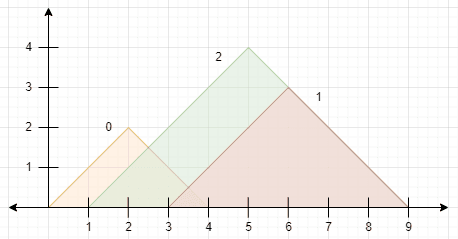

Input: peaks = [[2,2],[6,3],[5,4]]
Output: 2
Explanation: The diagram above shows the mountains.
- Mountain 0 is visible since its peak does not lie within another mountain or its sides.
- Mountain 1 is not visible since its peak lies within the side of mountain 2.
- Mountain 2 is visible since its peak does not lie within another mountain or its sides.
There are 2 mountains that are visible.

- Example 2

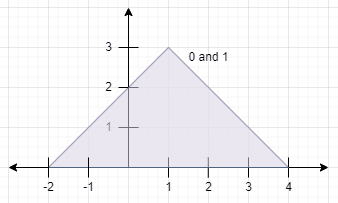

Input: peaks = [[1,3],[1,3]]
Output: 0
Explanation: The diagram above shows the mountains (they completely overlap).
Both mountains are not visible since their peaks lie within each other.

## Leetcode 1504. Count Submatrices With All Ones (Medium)

Given an m x n binary matrix mat, return the number of submatrices that have all ones.

- Example 1:

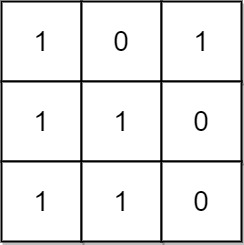

Input: mat = [[1,0,1],[1,1,0],[1,1,0]]
Output: 13

Explanation: 
There are 6 rectangles of side 1x1.
There are 2 rectangles of side 1x2.
There are 3 rectangles of side 2x1.
There is 1 rectangle of side 2x2. 
There is 1 rectangle of side 3x1.
Total number of rectangles = 6 + 2 + 3 + 1 + 1 = 13.
- Example 2:

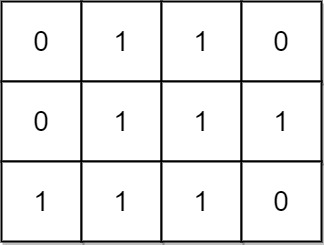

Input: mat = [[0,1,1,0],[0,1,1,1],[1,1,1,0]]
Output: 24

Explanation: 
There are 8 rectangles of side 1x1.
There are 5 rectangles of side 1x2.
There are 2 rectangles of side 1x3. 
There are 4 rectangles of side 2x1.
There are 2 rectangles of side 2x2. 
There are 2 rectangles of side 3x1. 
There is 1 rectangle of side 3x2. 
Total number of rectangles = 8 + 5 + 2 + 4 + 2 + 2 + 1 = 24.

## Leetcode 388. Longest Absolute File Path(Medium)

Suppose we have a file system that stores both files and directories. An example of one system is represented in the following picture:

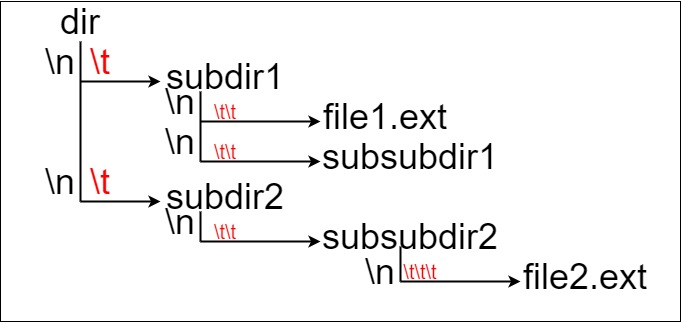

Here, we have dir as the only directory in the root. dir contains two subdirectories, subdir1 and subdir2. subdir1 contains a file file1.ext and subdirectory subsubdir1. subdir2 contains a subdirectory subsubdir2, which contains a file file2.ext.

In text form, it looks like this (with ⟶ representing the tab character):

dir
⟶ subdir1
⟶ ⟶ file1.ext
⟶ ⟶ subsubdir1
⟶ subdir2
⟶ ⟶ subsubdir2
⟶ ⟶ ⟶ file2.ext
If we were to write this representation in code, it will look like this: "dir\n\tsubdir1\n\t\tfile1.ext\n\t\tsubsubdir1\n\tsubdir2\n\t\tsubsubdir2\n\t\t\tfile2.ext". Note that the '\n' and '\t' are the new-line and tab characters.

Every file and directory has a unique absolute path in the file system, which is the order of directories that must be opened to reach the file/directory itself, all concatenated by '/'s. Using the above example, the absolute path to file2.ext is "dir/subdir2/subsubdir2/file2.ext". Each directory name consists of letters, digits, and/or spaces. Each file name is of the form name.extension, where name and extension consist of letters, digits, and/or spaces.

Given a string input representing the file system in the explained format, return the length of the longest absolute path to a file in the abstracted file system. If there is no file in the system, return 0.

Note that the testcases are generated such that the file system is valid and no file or directory name has length 0.

- Example 1:

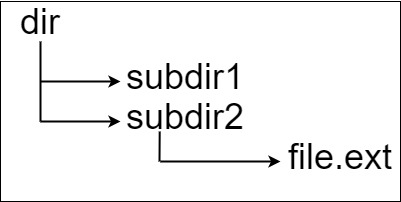

Input: input = "dir\n\tsubdir1\n\tsubdir2\n\t\tfile.ext"
Output: 20
Explanation: We have only one file, and the absolute path is "dir/subdir2/file.ext" of length 20.
- Example 2:

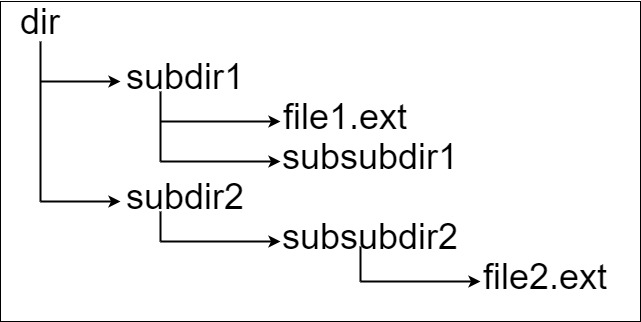

Input: input = "dir\n\tsubdir1\n\t\tfile1.ext\n\t\tsubsubdir1\n\tsubdir2\n\t\tsubsubdir2\n\t\t\tfile2.ext"
Output: 32
Explanation: We have two files:
"dir/subdir1/file1.ext" of length 21
"dir/subdir2/subsubdir2/file2.ext" of length 32.
We return 32 since it is the longest absolute path to a file.
Example 3:

Input: input = "a"
Output: 0
Explanation: We do not have any files, just a single directory named "a".

## Leetcode 895. Maximum Frequency Stack (Hard)
Design a stack-like data structure to push elements to the stack and pop the most frequent element from the stack.

Implement the FreqStack class:

FreqStack() constructs an empty frequency stack.
void push(int val) pushes an integer val onto the top of the stack.
int pop() removes and returns the most frequent element in the stack.
If there is a tie for the most frequent element, the element closest to the stack's top is removed and returned.
 

- Example 1:

Input
["FreqStack", "push", "push", "push", "push", "push", "push", "pop", "pop", "pop", "pop"]
[[], [5], [7], [5], [7], [4], [5], [], [], [], []]
Output
[null, null, null, null, null, null, null, 5, 7, 5, 4]

Explanation
FreqStack freqStack = new FreqStack();
freqStack.push(5); // The stack is [5]
freqStack.push(7); // The stack is [5,7]
freqStack.push(5); // The stack is [5,7,5]
freqStack.push(7); // The stack is [5,7,5,7]
freqStack.push(4); // The stack is [5,7,5,7,4]
freqStack.push(5); // The stack is [5,7,5,7,4,5]
freqStack.pop();   // return 5, as 5 is the most frequent. The stack becomes [5,7,5,7,4].
freqStack.pop();   // return 7, as 5 and 7 is the most frequent, but 7 is closest to the top. The stack becomes [5,7,5,4].
freqStack.pop();   // return 5, as 5 is the most frequent. The stack becomes [5,7,4].
freqStack.pop();   // return 4, as 4, 5 and 7 is the most frequent, but 4 is closest to the top. The stack becomes [5,7].

## Leetcode 2296. Design a Text Editor(Hard)

Design a text editor with a cursor that can do the following:

Add text to where the cursor is.
Delete text from where the cursor is (simulating the backspace key).
Move the cursor either left or right.
When deleting text, only characters to the left of the cursor will be deleted. The cursor will also remain within the actual text and cannot be moved beyond it. More formally, we have that 0 <= cursor.position <= currentText.length always holds.

Implement the TextEditor class:

- TextEditor() Initializes the object with empty text.
- void addText(string text) Appends text to where the cursor is. The cursor ends to the right of text.
- int deleteText(int k) Deletes k characters to the left of the cursor. Returns the number of characters actually deleted.
- string cursorLeft(int k) Moves the cursor to the left k times. Returns the last min(10, len) characters to the left of the cursor, where len is the number of characters to the left of the cursor.
- string cursorRight(int k) Moves the cursor to the right k times. Returns the last min(10, len) characters to the left of the cursor, where len is the number of characters to the left of the cursor.


## Leetcode 85. Maximal Rectangle (Hard)

Given a rows x cols binary matrix filled with 0's and 1's, find the largest rectangle containing only 1's and return its area.

- Example 1:

![image.png](attachment:d2c1d234-dad5-461f-975c-e58a870a15dc.png)

Input: matrix = [["1","0","1","0","0"],["1","0","1","1","1"],["1","1","1","1","1"],["1","0","0","1","0"]]
Output: 6
Explanation: The maximal rectangle is shown in the above picture.

- Example 2:

Input: matrix = [["0"]]
Output: 0

-Example 3:

Input: matrix = [["1"]]
Output: 1

## Leetcode 224. Basic Calculator (Hard)

Given a string s representing a valid expression, implement a basic calculator to evaluate it, and return the result of the evaluation.

Note: You are not allowed to use any built-in function which evaluates strings as mathematical expressions, such as eval().

- Example 1:

Input: s = "1 + 1"
Output: 2
- Example 2:

Input: s = " 2-1 + 2 "
Output: 3
Example 3:

Input: s = "(1+(4+5+2)-3)+(6+8)"
Output: 23

## Leetcode 591. Tag Validator(Hard)

Given a string representing a code snippet, implement a tag validator to parse the code and return whether it is valid.

A code snippet is valid if all the following rules hold:

The code must be wrapped in a valid closed tag. Otherwise, the code is invalid.
A closed tag (not necessarily valid) has exactly the following format : <TAG_NAME>TAG_CONTENT</TAG_NAME>. Among them, <TAG_NAME> is the start tag, and </TAG_NAME> is the end tag. The TAG_NAME in start and end tags should be the same. A closed tag is valid if and only if the TAG_NAME and TAG_CONTENT are valid.
A valid TAG_NAME only contain upper-case letters, and has length in range [1,9]. Otherwise, the TAG_NAME is invalid.
A valid TAG_CONTENT may contain other valid closed tags, cdata and any characters (see note1) EXCEPT unmatched <, unmatched start and end tag, and unmatched or closed tags with invalid TAG_NAME. Otherwise, the TAG_CONTENT is invalid.
A start tag is unmatched if no end tag exists with the same TAG_NAME, and vice versa. However, you also need to consider the issue of unbalanced when tags are nested.
A < is unmatched if you cannot find a subsequent >. And when you find a < or </, all the subsequent characters until the next > should be parsed as TAG_NAME (not necessarily valid).
The cdata has the following format : <![CDATA[CDATA_CONTENT]]>. The range of CDATA_CONTENT is defined as the characters between <![CDATA[ and the first subsequent ]]>.
CDATA_CONTENT may contain any characters. The function of cdata is to forbid the validator to parse CDATA_CONTENT, so even it has some characters that can be parsed as tag (no matter valid or invalid), you should treat it as regular characters.
 

Example 1:

Input: code = "<DIV>This is the first line <![CDATA[<div>]]></DIV>"
Output: true
Explanation: 
The code is wrapped in a closed tag : <DIV> and </DIV>. 
The TAG_NAME is valid, the TAG_CONTENT consists of some characters and cdata. 
Although CDATA_CONTENT has an unmatched start tag with invalid TAG_NAME, it should be considered as plain text, not parsed as a tag.
So TAG_CONTENT is valid, and then the code is valid. Thus return true.
Example 2:

Input: code = "<DIV>>>  ![cdata[]] <![CDATA[<div>]>]]>]]>>]</DIV>"
Output: true
Explanation:
We first separate the code into : start_tag|tag_content|end_tag.
start_tag -> "<DIV>"
end_tag -> "</DIV>"
tag_content could also be separated into : text1|cdata|text2.
text1 -> ">>  ![cdata[]] "
cdata -> "<![CDATA[<div>]>]]>", where the CDATA_CONTENT is "<div>]>"
text2 -> "]]>>]"
The reason why start_tag is NOT "<DIV>>>" is because of the rule 6.
The reason why cdata is NOT "<![CDATA[<div>]>]]>]]>" is because of the rule 7.
Example 3:

Input: code = "<A>  <B> </A>   </B>"
Output: false
Explanation: Unbalanced. If "<A>" is closed, then "<B>" must be unmatched, and vice versa.

# Queue

## Leetcode 622. Design Circular Queue (Medium)

Design your implementation of the circular queue. The circular queue is a linear data structure in which the operations are performed based on FIFO (First In First Out) principle, and the last position is connected back to the first position to make a circle. It is also called "Ring Buffer".

One of the benefits of the circular queue is that we can make use of the spaces in front of the queue. In a normal queue, once the queue becomes full, we cannot insert the next element even if there is a space in front of the queue. But using the circular queue, we can use the space to store new values.

- Implement the MyCircularQueue class:

    - MyCircularQueue(k) Initializes the object with the size of the queue to be k.
    - int Front() Gets the front item from the queue. If the queue is empty, return -1.
    - int Rear() Gets the last item from the queue. If the queue is empty, return -1.
    - boolean enQueue(int value) Inserts an element into the circular queue. Return true if the operation is successful.
    - boolean deQueue() Deletes an element from the circular queue. Return true if the operation is successful.
    - boolean isEmpty() Checks whether the circular queue is empty or not.
    - boolean isFull() Checks whether the circular queue is full or not.
You must solve the problem without using the built-in queue data structure in your programming language. 

- Example 1:

Input
["MyCircularQueue", "enQueue", "enQueue", "enQueue", "enQueue", "Rear", "isFull", "deQueue", "enQueue", "Rear"]
[[3], [1], [2], [3], [4], [], [], [], [4], []]
Output
[null, true, true, true, false, 3, true, true, true, 4]


Explanation
```
MyCircularQueue myCircularQueue = new MyCircularQueue(3);
myCircularQueue.enQueue(1); // return True
myCircularQueue.enQueue(2); // return True
myCircularQueue.enQueue(3); // return True
myCircularQueue.enQueue(4); // return False
myCircularQueue.Rear();     // return 3
myCircularQueue.isFull();   // return True
myCircularQueue.deQueue();  // return True
myCircularQueue.enQueue(4); // return True
myCircularQueue.Rear();     // return 4
```

## Leetcode 641. Design Circular Deque (Medium)

Design your implementation of the circular double-ended queue (deque).

- Implement the MyCircularDeque class:

    - MyCircularDeque(int k) Initializes the deque with a maximum size of k.
    - boolean insertFront() Adds an item at the front of Deque. Returns true if the operation is successful, or false otherwise.
    - boolean insertLast() Adds an item at the rear of Deque. Returns true if the operation is successful, or false otherwise.
    - boolean deleteFront() Deletes an item from the front of Deque. Returns true if the operation is successful, or false otherwise.
    - boolean deleteLast() Deletes an item from the rear of Deque. Returns true if the operation is successful, or false otherwise.
    - int getFront() Returns the front item from the Deque. Returns -1 if the deque is empty.
    - int getRear() Returns the last item from Deque. Returns -1 if the deque is empty.
    - boolean isEmpty() Returns true if the deque is empty, or false otherwise.
    - boolean isFull() Returns true if the deque is full, or false otherwise.
 

- Example 1:

Input
["MyCircularDeque", "insertLast", "insertLast", "insertFront", "insertFront", "getRear", "isFull", "deleteLast", "insertFront", "getFront"]
[[3], [1], [2], [3], [4], [], [], [], [4], []]
Output
[null, true, true, true, false, 2, true, true, true, 4]

Explanation
```
MyCircularDeque myCircularDeque = new MyCircularDeque(3);
myCircularDeque.insertLast(1);  // return True
myCircularDeque.insertLast(2);  // return True
myCircularDeque.insertFront(3); // return True
myCircularDeque.insertFront(4); // return False, the queue is full.
myCircularDeque.getRear();      // return 2
myCircularDeque.isFull();       // return True
myCircularDeque.deleteLast();   // return True
myCircularDeque.insertFront(4); // return True
myCircularDeque.getFront();     // return 4
```

## Leetcode 1670. Design Front Middle Back Queue(Medium)

Design a queue that supports push and pop operations in the front, middle, and back.

- Implement the FrontMiddleBack class:

    - FrontMiddleBack() Initializes the queue.
    - void pushFront(int val) Adds val to the front of the queue.
    - void pushMiddle(int val) Adds val to the middle of the queue.
    - void pushBack(int val) Adds val to the back of the queue.
    - int popFront() Removes the front element of the queue and returns it. If the queue is empty, return -1.
    - int popMiddle() Removes the middle element of the queue and returns it. If the queue is empty, return -1.
    - int popBack() Removes the back element of the queue and returns it. If the queue is empty, return -1.

Notice that when there are two middle position choices, the operation is performed on the frontmost middle position choice. For example:

Pushing 6 into the middle of [1, 2, 3, 4, 5] results in [1, 2, 6, 3, 4, 5].
Popping the middle from [1, 2, 3, 4, 5, 6] returns 3 and results in [1, 2, 4, 5, 6].

- Example 1:

Input:
["FrontMiddleBackQueue", "pushFront", "pushBack", "pushMiddle", "pushMiddle", "popFront", "popMiddle", "popMiddle", "popBack", "popFront"]
[[], [1], [2], [3], [4], [], [], [], [], []]

Output:
[null, null, null, null, null, 1, 3, 4, 2, -1]

Explanation:

```
FrontMiddleBackQueue q = new FrontMiddleBackQueue();
q.pushFront(1);   // [1]
q.pushBack(2);    // [1, 2]
q.pushMiddle(3);  // [1, 3, 2]
q.pushMiddle(4);  // [1, 4, 3, 2]
q.popFront();     // return 1 -> [4, 3, 2]
q.popMiddle();    // return 3 -> [4, 2]
q.popMiddle();    // return 4 -> [2]
q.popBack();      // return 2 -> []
q.popFront();     // return -1 -> [] (The queue is empty)
```

## Leetcode 225. Implement Stack using Queues

Description:
Implement the following operations of a stack using queues.

push(x) -- Push element x onto stack.

pop() -- Removes the element on top of the stack.

top() -- Get the top element.

empty() -- Return whether the stack is empty.

- Example 1:

Input
["MyStack", "push", "push", "top", "pop", "empty"]
[[], [1], [2], [], [], []]

Output
[null, null, null, 2, 2, false]

Explanation

MyStack myStack = new MyStack();

myStack.push(1);

myStack.push(2);

myStack.top(); // return 2

myStack.pop(); // return 2

myStack.empty(); // return False

In [54]:
from collections import deque
class MyStack():
    def __init__(self):
        self.queue1 = deque()
        self.queue2 = deque()
    def push(self, num):
        self.queue1.append(num)
        while self.queue2:
            self.queue1.append(self.queue2.popleft())
        self.queue1, self.queue2,  = self.queue2, self.queue1
    def pop(self):
        return self.queue2.popleft()
    def top(self):
        return self.queue2[0]
    def empty(self):
        return len(self.queue2)==0

In [55]:
myStack = MyStack()
myStack.push(1)
myStack.push(2)
myStack.top()

2

In [56]:
myStack.pop()

2

In [57]:
myStack.empty()

False

## Leetcode 933. Number of Recent Calls

Description:
Write a class RecentCounter to count recent requests.

It has only one method: ping(int t), where t represents some time in milliseconds.

Return the number of pings that have been made from 3000 milliseconds ago until now.

Any ping with time in [t - 3000, t] will count, including the current ping.

It is guaranteed that every call to ping uses a strictly larger value of t than before.

Note:
Each test case will have at most 10000 calls to ping.
Each test case will call ping with strictly increasing values of t.
Each call to ping will have 1 <= t <= 10^9.

- Example 1:

Input
["RecentCounter", "ping", "ping", "ping", "ping"]
[[], [1], [100], [3001], [3002]]
Output
[null, 1, 2, 3, 3]

Explanation

RecentCounter recentCounter = new RecentCounter();

recentCounter.ping(1);     // requests = [1], range is [-2999,1], return 1

recentCounter.ping(100);   // requests = [1, 100], range is [-2900,100], return 2

recentCounter.ping(3001);  // requests = [1, 100, 3001], range is [1,3001], return 3

recentCounter.ping(3002);  // requests = [1, 100, 3001, 3002], range is [2,3002], return 3

In [20]:
from collections import deque
class RecentCounter():
    def __init__(self):
        self.queue = deque()
    def ping(self, num):
        lower = num - 3000
        higher = num
        self.queue.append(num)
        while self.queue[0] < lower:
            self.queue.popleft()
        return len(self.queue)

In [21]:
counter = RecentCounter()
counter.ping(1)

1

In [22]:
counter.ping(100)

2

In [23]:
counter.ping(3001)

3

In [24]:
counter.ping(3002)

3

## Leetcode 346. Moving Average from Data Stream
Given a stream of integers and a window size, calculate the moving average of all integers in the sliding window.

- Example:

MovingAverage m = new MovingAverage(3);
m.next(1) = 1
m.next(10) = (1 + 10) / 2
m.next(3) = (1 + 10 + 3) / 3
m.next(5) = (10 + 3 + 5) / 3

## Leetcode 1700. Number of Students Unable to Eat Lunch

The school cafeteria offers circular and square sandwiches at lunch break, referred to by numbers 0 and 1 respectively. All students stand in a queue. Each student either prefers square or circular sandwiches.

The number of sandwiches in the cafeteria is equal to the number of students. The sandwiches are placed in a stack. At each step:

If the student at the front of the queue prefers the sandwich on the top of the stack, they will take it and leave the queue.
Otherwise, they will leave it and go to the queue's end.
This continues until none of the queue students want to take the top sandwich and are thus unable to eat.

You are given two integer arrays students and sandwiches where sandwiches[i] is the type of the i​​​​​​th sandwich in the stack (i = 0 is the top of the stack) and students[j] is the preference of the j​​​​​​th student in the initial queue (j = 0 is the front of the queue). Return the number of students that are unable to eat.

 

Example 1:

Input: students = [1,1,0,0], sandwiches = [0,1,0,1]
Output: 0 
Explanation:
- Front student leaves the top sandwich and returns to the end of the line making students = [1,0,0,1].
- Front student leaves the top sandwich and returns to the end of the line making students = [0,0,1,1].
- Front student takes the top sandwich and leaves the line making students = [0,1,1] and sandwiches = [1,0,1].
- Front student leaves the top sandwich and returns to the end of the line making students = [1,1,0].
- Front student takes the top sandwich and leaves the line making students = [1,0] and sandwiches = [0,1].
- Front student leaves the top sandwich and returns to the end of the line making students = [0,1].
- Front student takes the top sandwich and leaves the line making students = [1] and sandwiches = [1].
- Front student takes the top sandwich and leaves the line making students = [] and sandwiches = [].
Hence all students are able to eat.
Example 2:

Input: students = [1,1,1,0,0,1], sandwiches = [1,0,0,0,1,1]
Output: 3

## Leetcode 281. Zigzag Iterator(Medium)
Given two 1d vectors, implement an iterator to return their elements alternately.

Example:

Input:
v1 = [1,2]
v2 = [3,4,5,6]

Output: [1,3,2,4,5,6]

Explanation: By calling next repeatedly until hasNext returns false,
             the order of elements returned by next should be: [1,3,2,4,5,6].
Follow up: What if you are given k 1d vectors? How well can your code be extended to such cases?

## Leetcode 362. Design Hit Counter
Design a hit counter which counts the number of hits received in the past 5 minutes.

Each function accepts a timestamp parameter (in seconds granularity) and you may assume that calls are being made to the system in chronological order (ie, the timestamp is monotonically increasing). You may assume that the earliest timestamp starts at 1.ISPs

It is possible that several hits arrive roughly at the same time.

- Example:

HitCounter counter = new HitCounter();

// hit at timestamp 1.
counter.hit(1);

// hit at timestamp 2.
counter.hit(2);

// hit at timestamp 3.
counter.hit(3);

// get hits at timestamp 4, should return 3.
counter.getHits(4);

// hit at timestamp 300.
counter.hit(300);

// get hits at timestamp 300, should return 4.
counter.getHits(300);

// get hits at timestamp 301, should return 3.
counter.getHits(301);

Follow up:
What if the number of hits per second could be very large? Does your  design scale?

## Leetcode 121. Best Time to Buy and Sell Stock

Description:
Say you have an array for which the ith element is the price of a given stock on day i.

If you were only permitted to complete at most one transaction (i.e., buy one and sell one share of the stock), design an algorithm to find the maximum profit.

Note that you cannot sell a stock before you buy one.

- Example 1:
Input: [7,1,5,3,6,4]

Output: 5

Explanation:
Buy on day 2 (price = 1) and sell on day 5 (price = 6), profit = 6-1 = 5.

Not 7-1 = 6, as selling price needs to be larger than buying price.

- Example 2:
Input: [7,6,4,3,1]

Output: 0

Explanation:
In this case, no transaction is done, i.e. max profit = 0.

## Leetcode 1438. Longest Continuous Subarray With Absolute Diff Less Than or Equal to Limit (Medium)

Given an array of integers nums and an integer limit, return the size of the longest non-empty subarray such that the absolute difference between any two elements of this subarray is less than or equal to limit.

- Example 1:

Input: nums = [8,2,4,7], limit = 4
Output: 2 
Explanation: All subarrays are: 
```
[8] with maximum absolute diff |8-8| = 0 <= 4.
[8,2] with maximum absolute diff |8-2| = 6 > 4. 
[8,2,4] with maximum absolute diff |8-2| = 6 > 4.
[8,2,4,7] with maximum absolute diff |8-2| = 6 > 4.
[2] with maximum absolute diff |2-2| = 0 <= 4.
[2,4] with maximum absolute diff |2-4| = 2 <= 4.
[2,4,7] with maximum absolute diff |2-7| = 5 > 4.
[4] with maximum absolute diff |4-4| = 0 <= 4.
[4,7] with maximum absolute diff |4-7| = 3 <= 4.
[7] with maximum absolute diff |7-7| = 0 <= 4. 
```
Therefore, the size of the longest subarray is 2.
- Example 2:

Input: nums = [10,1,2,4,7,2], limit = 5
Output: 4 

Explanation: The subarray [2,4,7,2] is the longest since the maximum absolute diff is |2-7| = 5 <= 5.
- Example 3:

Input: nums = [4,2,2,2,4,4,2,2], limit = 0
Output: 3

## Leetcoe 1823. Find the Winner of the Circular Game (Medium)

There are n friends that are playing a game. The friends are sitting in a circle and are numbered from 1 to n in clockwise order. More formally, moving clockwise from the ith friend brings you to the (i+1)th friend for 1 <= i < n, and moving clockwise from the nth friend brings you to the 1st friend.

The rules of the game are as follows:

Start at the 1st friend.
Count the next k friends in the clockwise direction including the friend you started at. The counting wraps around the circle and may count some friends more than once.
The last friend you counted leaves the circle and loses the game.
If there is still more than one friend in the circle, go back to step 2 starting from the friend immediately clockwise of the friend who just lost and repeat.
Else, the last friend in the circle wins the game.
Given the number of friends, n, and an integer k, return the winner of the game.

Example 1:


Input: n = 5, k = 2
Output: 3
Explanation: Here are the steps of the game:
```
1) Start at friend 1.
2) Count 2 friends clockwise, which are friends 1 and 2.
3) Friend 2 leaves the circle. Next start is friend 3.
4) Count 2 friends clockwise, which are friends 3 and 4.
5) Friend 4 leaves the circle. Next start is friend 5.
6) Count 2 friends clockwise, which are friends 5 and 1.
7) Friend 1 leaves the circle. Next start is friend 3.
8) Count 2 friends clockwise, which are friends 3 and 5.
9) Friend 5 leaves the circle. Only friend 3 is left, so they are the winner.
```
- Example 2:

Input: n = 6, k = 5
Output: 1
Explanation: The friends leave in this order: 5, 4, 6, 2, 3. The winner is friend 1.

## Leetcode 950. Reveal Cards In Increasing Order (Medium)

You are given an integer array deck. There is a deck of cards where every card has a unique integer. The integer on the ith card is deck[i].

You can order the deck in any order you want. Initially, all the cards start face down (unrevealed) in one deck.

You will do the following steps repeatedly until all cards are revealed:

Take the top card of the deck, reveal it, and take it out of the deck.
If there are still cards in the deck then put the next top card of the deck at the bottom of the deck.
If there are still unrevealed cards, go back to step 1. Otherwise, stop.
Return an ordering of the deck that would reveal the cards in increasing order.

Note that the first entry in the answer is considered to be the top of the deck.

 

Example 1:

Input: deck = [17,13,11,2,3,5,7]
Output: [2,13,3,11,5,17,7]
Explanation: 
We get the deck in the order [17,13,11,2,3,5,7] (this order does not matter), and reorder it.
After reordering, the deck starts as [2,13,3,11,5,17,7], where 2 is the top of the deck.
We reveal 2, and move 13 to the bottom.  The deck is now [3,11,5,17,7,13].
We reveal 3, and move 11 to the bottom.  The deck is now [5,17,7,13,11].
We reveal 5, and move 17 to the bottom.  The deck is now [7,13,11,17].
We reveal 7, and move 13 to the bottom.  The deck is now [11,17,13].
We reveal 11, and move 17 to the bottom.  The deck is now [13,17].
We reveal 13, and move 17 to the bottom.  The deck is now [17].
We reveal 17.
Since all the cards revealed are in increasing order, the answer is correct.
Example 2:

Input: deck = [1,1000]
Output: [1,1000]

## Leetcode 2327. Number of People Aware of a Secret (Medium)

On day 1, one person discovers a secret.

You are given an integer delay, which means that each person will share the secret with a new person every day, starting from delay days after discovering the secret. You are also given an integer forget, which means that each person will forget the secret forget days after discovering it. A person cannot share the secret on the same day they forgot it, or on any day afterwards.

Given an integer n, return the number of people who know the secret at the end of day n. Since the answer may be very large, return it modulo 109 + 7.

Example 1:

Input: n = 6, delay = 2, forget = 4
Output: 5
Explanation:
```
Day 1: Suppose the first person is named A. (1 person)
Day 2: A is the only person who knows the secret. (1 person)
Day 3: A shares the secret with a new person, B. (2 people)
Day 4: A shares the secret with a new person, C. (3 people)
Day 5: A forgets the secret, and B shares the secret with a new person, D. (3 people)
Day 6: B shares the secret with E, and C shares the secret with F. (5 people)
```
Example 2:

Input: n = 4, delay = 1, forget = 3
Output: 6

Explanation:
```
Day 1: The first person is named A. (1 person)
Day 2: A shares the secret with B. (2 people)
Day 3: A and B share the secret with 2 new people, C and D. (4 people)
Day 4: A forgets the secret. B, C, and D share the secret with 3 new people. (6 people)
```

## Leetcode 918. Maximum Sum Circular Subarray (Medium)

Given a circular integer array nums of length n, return the maximum possible sum of a non-empty subarray of nums.

A circular array means the end of the array connects to the beginning of the array. Formally, the next element of nums[i] is nums[(i + 1) % n] and the previous element of nums[i] is nums[(i - 1 + n) % n].

A subarray may only include each element of the fixed buffer nums at most once. Formally, for a subarray nums[i], nums[i + 1], ..., nums[j], there does not exist i <= k1, k2 <= j with k1 % n == k2 % n.

Example 1:

Input: nums = [1,-2,3,-2]
Output: 3
Explanation: Subarray [3] has maximum sum 3.
Example 2:

Input: nums = [5,-3,5]
Output: 10
Explanation: Subarray [5,5] has maximum sum 5 + 5 = 10.
Example 3:

Input: nums = [-3,-2,-3]
Output: -2
Explanation: Subarray [-2] has maximum sum -2.

## Leetcode 1687. Delivering Boxes from Storage to Ports (Hard)

You have the task of delivering some boxes from storage to their ports using only one ship. However, this ship has a limit on the number of boxes and the total weight that it can carry.

You are given an array boxes, where $boxes[i] = [ports_i, weight_i]$, and three integers portsCount, maxBoxes, and maxWeight.

portsi is the port where you need to deliver the ith box and weightsi is the weight of the ith box.
portsCount is the number of ports.
maxBoxes and maxWeight are the respective box and weight limits of the ship.
The boxes need to be delivered in the order they are given. The ship will follow these steps:

The ship will take some number of boxes from the boxes queue, not violating the maxBoxes and maxWeight constraints.
For each loaded box in order, the ship will make a trip to the port the box needs to be delivered to and deliver it. If the ship is already at the correct port, no trip is needed, and the box can immediately be delivered.
The ship then makes a return trip to storage to take more boxes from the queue.
The ship must end at storage after all the boxes have been delivered.

Return the minimum number of trips the ship needs to make to deliver all boxes to their respective ports.

- Example 1:

Input: boxes = [[1,1],[2,1],[1,1]], portsCount = 2, maxBoxes = 3, maxWeight = 3
Output: 4

Explanation: The optimal strategy is as follows: 

The ship takes all the boxes in the queue, goes to port 1, then port 2, then port 1 again, then returns to storage. 4 trips.
So the total number of trips is 4.
Note that the first and third boxes cannot be delivered together because the boxes need to be delivered in order (i.e. the second box needs to be delivered at port 2 before the third box).
- Example 2:

Input: boxes = [[1,2],[3,3],[3,1],[3,1],[2,4]], portsCount = 3, maxBoxes = 3, maxWeight = 6
Output: 6
Explanation: The optimal strategy is as follows: 
- The ship takes the first box, goes to port 1, then returns to storage. 2 trips.
- The ship takes the second, third and fourth boxes, goes to port 3, then returns to storage. 2 trips.
- The ship takes the fifth box, goes to port 2, then returns to storage. 2 trips.
So the total number of trips is 2 + 2 + 2 = 6.
- Example 3:

Input: boxes = [[1,4],[1,2],[2,1],[2,1],[3,2],[3,4]], portsCount = 3, maxBoxes = 6, maxWeight = 7
Output: 6

Explanation: The optimal strategy is as follows:
    - The ship takes the first and second boxes, goes to port 1, then returns to storage. 2 trips.
    - The ship takes the third and fourth boxes, goes to port 2, then returns to storage. 2 trips.
    - The ship takes the fifth and sixth boxes, goes to port 3, then returns to storage. 2 trips.
So the total number of trips is 2 + 2 + 2 = 6.

## Leetcode 2532. Time to Cross a Bridge (Hard)

There are k workers who want to move n boxes from the right (old) warehouse to the left (new) warehouse. You are given the two integers n and k, and a 2D integer array time of size k x 4 where time[i] = [righti, picki, lefti, puti].

The warehouses are separated by a river and connected by a bridge. Initially, all k workers are waiting on the left side of the bridge. To move the boxes, the ith worker can do the following:

Cross the bridge to the right side in righti minutes.
Pick a box from the right warehouse in picki minutes.
Cross the bridge to the left side in lefti minutes.
Put the box into the left warehouse in puti minutes.
The ith worker is less efficient than the jth worker if either condition is met:

lefti + righti > leftj + rightj
lefti + righti == leftj + rightj and i > j
The following rules regulate the movement of the workers through the bridge:

Only one worker can use the bridge at a time.
When the bridge is unused prioritize the least efficient worker (who have picked up the box) on the right side to cross. If not, prioritize the least efficient worker on the left side to cross.
If enough workers have already been dispatched from the left side to pick up all the remaining boxes, no more workers will be sent from the left side.
Return the elapsed minutes at which the last box reaches the left side of the bridge.

Example 1:

Input: n = 1, k = 3, time = [[1,1,2,1],[1,1,3,1],[1,1,4,1]]

Output: 6

Explanation:
```
From 0 to 1 minutes: worker 2 crosses the bridge to the right.
From 1 to 2 minutes: worker 2 picks up a box from the right warehouse.
From 2 to 6 minutes: worker 2 crosses the bridge to the left.
From 6 to 7 minutes: worker 2 puts a box at the left warehouse.
```
The whole process ends after 7 minutes. We return 6 because the problem asks for the instance of time at which the last worker reaches the left side of the bridge.
- Example 2:

Input: n = 3, k = 2, time = [[1,5,1,8],[10,10,10,10]]

Output: 37

Explanation:

The last box reaches the left side at 37 seconds. Notice, how we do not put the last bo

## Leetcode 239. Sliding Window Maximum (Hard)

You are given an array of integers nums, there is a sliding window of size k which is moving from the very left of the array to the very right. You can only see the k numbers in the window. Each time the sliding window moves right by one position.

Return the max sliding window.

 

- Example 1:

Input: nums = [1,3,-1,-3,5,3,6,7], k = 3
Output: [3,3,5,5,6,7]
Explanation: 
Window position                Max
---------------               -----
[1  3  -1] -3  5  3  6  7       3
 1 [3  -1  -3] 5  3  6  7       3
 1  3 [-1  -3  5] 3  6  7       5
 1  3  -1 [-3  5  3] 6  7       5
 1  3  -1  -3 [5  3  6] 7       6
 1  3  -1  -3  5 [3  6  7]      7
- Example 2:

Input: nums = [1], k = 1
Output: [1]

## Leetcode 995. Minimum Number of K Consecutive Bit Flips (Hard)

You are given a binary array nums and an integer k.

A k-bit flip is choosing a subarray of length k from nums and simultaneously changing every 0 in the subarray to 1, and every 1 in the subarray to 0.

Return the minimum number of k-bit flips required so that there is no 0 in the array. If it is not possible, return -1.

A subarray is a contiguous part of an array.

- Example 1:

Input: nums = [0,1,0], k = 1
Output: 2
Explanation: Flip nums[0], then flip nums[2].
- Example 2:

Input: nums = [1,1,0], k = 2
Output: -1
Explanation: No matter how we flip subarrays of size 2, we cannot make the array become [1,1,1].
- Example 3:

Input: nums = [0,0,0,1,0,1,1,0], k = 3
Output: 3
Explanation: 
Flip nums[0],nums[1],nums[2]: nums becomes [1,1,1,1,0,1,1,0]
Flip nums[4],nums[5],nums[6]: nums becomes [1,1,1,1,1,0,0,0]
Flip nums[5],nums[6],nums[7]: nums becomes [1,1,1,1,1,1,1,1]
 

## Leetcode 1425. Constrained Subsequence Sum (Hard)

Given an integer array nums and an integer k, return the maximum sum of a non-empty subsequence of that array such that for every two consecutive integers in the subsequence, nums[i] and nums[j], where i < j, the condition j - i <= k is satisfied.

A subsequence of an array is obtained by deleting some number of elements (can be zero) from the array, leaving the remaining elements in their original order.

Example 1:

Input: nums = [10,2,-10,5,20], k = 2
Output: 37
Explanation: The subsequence is [10, 2, 5, 20].
Example 2:

Input: nums = [-1,-2,-3], k = 1
Output: -1
Explanation: The subsequence must be non-empty, so we choose the largest number.
Example 3:

Input: nums = [10,-2,-10,-5,20], k = 2
Output: 23
Explanation: The subsequence is [10, -2, -5, 20].

## Leetcode 1499. Max Value of Equation (Hard)

You are given an array points containing the coordinates of points on a 2D plane, sorted by the x-values, where points[i] = [xi, yi] such that xi < xj for all 1 <= i < j <= points.length. You are also given an integer k.

Return the maximum value of the equation yi + yj + |xi - xj| where |xi - xj| <= k and 1 <= i < j <= points.length.

It is guaranteed that there exists at least one pair of points that satisfy the constraint |xi - xj| <= k.

- Example 1:

Input: points = [[1,3],[2,0],[5,10],[6,-10]], k = 1
Output: 4
Explanation: The first two points satisfy the condition |xi - xj| <= 1 and if we calculate the equation we get 3 + 0 + |1 - 2| = 4. Third and fourth points also satisfy the condition and give a value of 10 + -10 + |5 - 6| = 1.
No other pairs satisfy the condition, so we return the max of 4 and 1.
- Example 2:

Input: points = [[0,0],[3,0],[9,2]], k = 3
Output: 3
Explanation: Only the first two points have an absolute difference of 3 or less in the x-values, and give the value of 0 + 0 + |0 - 3| = 3.